# Hot Cracking Screening — Multi-Alloy Comparison

**Repository**: matreum/am-solidification-screening | **Notebook 02**

## Purpose

Apply three established hot-cracking susceptibility criteria to Scheil solidification
curves of two AM alloys: **316L SS** and **AlSi10Mg**. This translates raw solidification
data into actionable cracking risk indicators.

> **Note**: Ti-6Al-4V and IN718 require commercial thermodynamic databases (TCTI, TCNI)
> not included in this open-source repository. The methodology demonstrated here
> generalizes to any alloy system with a CALPHAD database.

### The Three Criteria

| Criterion | Published | What It Measures |
|-----------|-----------|-----------------|
| Kou (2003) | Acta Materialia 51, 4325 | Steepness of T vs. f_s^(1/2) at terminal solidification |
| Clyne-Davies (1981) | British Foundryman 74, 65 | Time ratio in vulnerable vs. stress-relaxation regimes |
| RDG (1999) | Met. Trans. A 30, 449 | Feeding resistance in the mushy zone critical fraction range |

In [1]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))

from matreum_am_screening.core import (
    run_scheil, ALLOY_316L, ALLOY_ALSI10MG,
    kou_index, clyne_davies, rdg_index, printability_summary
)
from matreum_am_screening.plotting import (
    plot_kou_derivative, plot_clyne_davies_intervals,
    plot_rdg_integrand, plot_cracking_ranking
)

plt.rcParams['figure.dpi'] = 120
print("Dependencies loaded.")

Dependencies loaded.


In [2]:
# Run Scheil simulations
print("Running 316L Scheil simulation...")
res_316L = run_scheil(ALLOY_316L)
print(f"  316L: {res_316L.T_liquidus_C:.0f} → {res_316L.T_solidus_C:.0f} °C (ΔT = {res_316L.solidification_range_C:.0f} °C)")

print("Running AlSi10Mg Scheil simulation...")
res_AlSi = run_scheil(ALLOY_ALSI10MG)
print(f"  AlSi10Mg: {res_AlSi.T_liquidus_C:.0f} → {res_AlSi.T_solidus_C:.0f} °C (ΔT = {res_AlSi.solidification_range_C:.0f} °C)")

results = {"316L SS": res_316L, "AlSi10Mg": res_AlSi}
print("\nBoth simulations complete.")

Running 316L Scheil simulation...


  316L: 1433 → 1155 °C (ΔT = 278 °C)
Running AlSi10Mg Scheil simulation...


  AlSi10Mg: 594 → 557 °C (ΔT = 37 °C)

Both simulations complete.


## Kou Criterion (2003)

**Physical basis**: Solidification cracking occurs when terminal liquid films between grains
cannot accommodate shrinkage strain. The steeper the solidification curve at high fraction
solid, the more difficult it is for liquid to flow and heal nascent cracks.

$$\text{CSC}_{\text{Kou}} = \max \left| \frac{dT}{d\sqrt{f_s}} \right| \quad \text{evaluated near } f_s \to 1$$

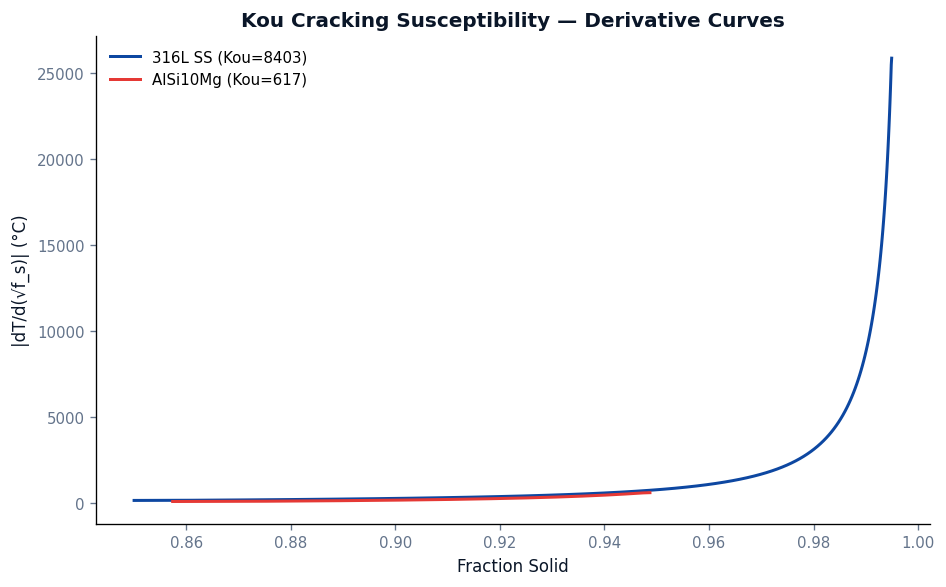

In [3]:
fig = plot_kou_derivative(results)
plt.show()

## Clyne-Davies Criterion (1981)

**Physical basis**: The ratio of time spent in the vulnerable zone (f_s = 0.90–0.99, where
liquid is trapped and cannot feed shrinkage) to the relaxation zone (f_s = 0.40–0.90, where
liquid is interconnected and strain can relax).

$$\text{CSC}_{\text{CD}} = \frac{\Delta T_{\text{vulnerable}}}{\Delta T_{\text{relaxation}}} = \frac{T(f_s{=}0.90) - T(f_s{=}0.99)}{T(f_s{=}0.40) - T(f_s{=}0.90)}$$

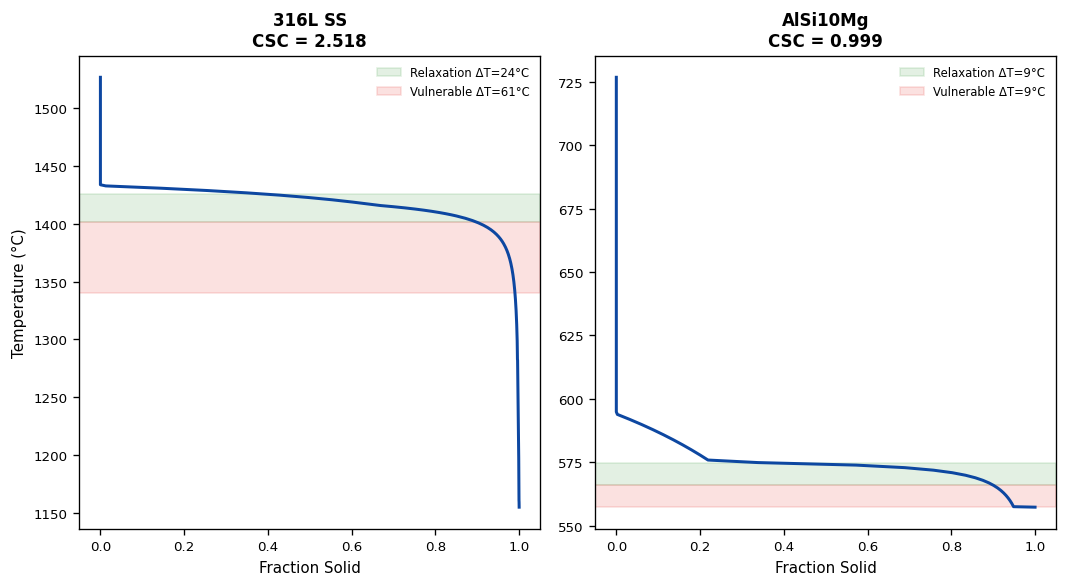

In [4]:
fig = plot_clyne_davies_intervals(results)
plt.show()

## Simplified RDG Criterion (1999)

**Physical basis**: Cracking occurs when the pressure drop in the mushy zone exceeds the
cavitation pressure. The simplified index integrates the feeding resistance in the critical
fraction solid range without requiring process-specific thermal gradient and strain rate inputs.

$$\text{RDG}_{\text{index}} = \int_{0.90}^{0.99} \frac{f_s^2}{(1 - f_s)^3} \cdot \left| \frac{dT}{df_s} \right|^{-1} df_s$$

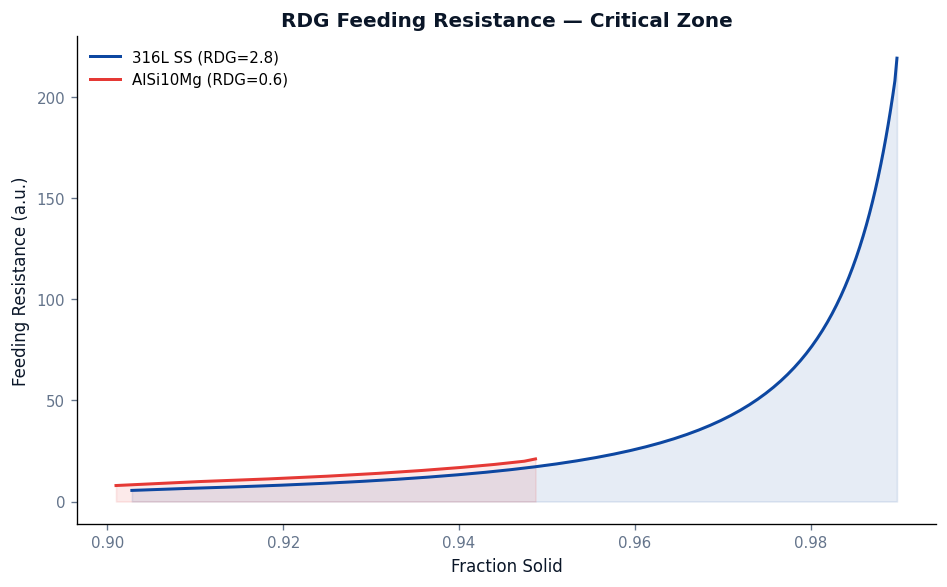

In [5]:
fig = plot_rdg_integrand(results)
plt.show()

## Combined Ranking

In [6]:
# Build comparison table
df = printability_summary(results)
print("\nRaw Cracking Metrics:")
print("=" * 70)
for _, row in df.iterrows():
    print(f"\n{row['alloy']}:")
    print(f"  Solidification range:  {row['delta_T_C']:.1f} °C")
    print(f"  Kou index:             {row['CSC_Kou']:.1f} °C")
    print(f"  Clyne-Davies CSC:      {row['CSC_CD']:.4f}")
    print(f"  RDG index:             {row['RDG_index']:.2f}")
    print(f"  CPI (lower = better):  {row['CPI']:.3f}  [Rank: {row['Rank']}]")


Raw Cracking Metrics:

316L SS:
  Solidification range:  278.1 °C
  Kou index:             8403.3 °C
  Clyne-Davies CSC:      2.5176
  RDG index:             2.81
  CPI (lower = better):  1.000  [Rank: 2]

AlSi10Mg:
  Solidification range:  36.6 °C
  Kou index:             616.7 °C
  Clyne-Davies CSC:      0.9991
  RDG index:             0.62
  CPI (lower = better):  0.000  [Rank: 1]


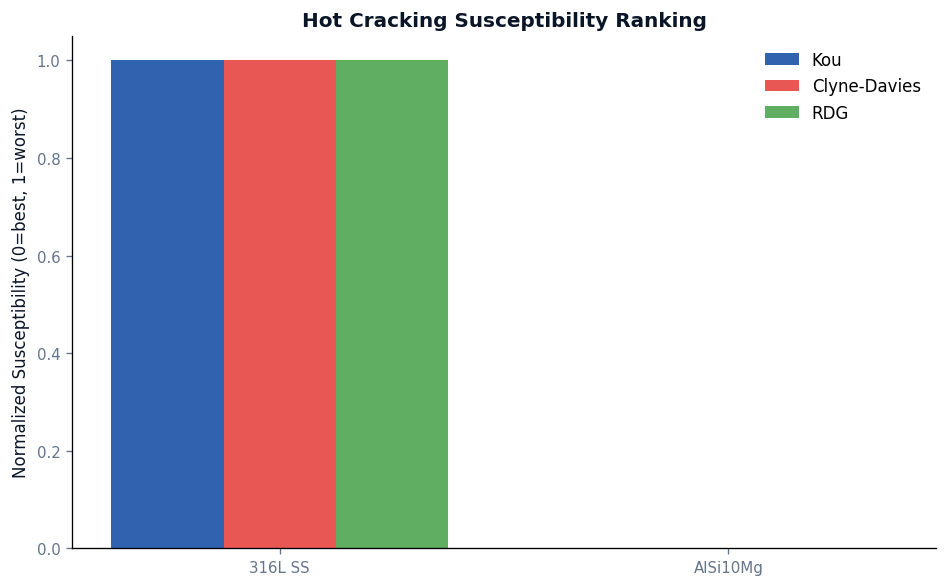

In [7]:
fig = plot_cracking_ranking(df)
plt.show()

## Stated Limitations

1. **All three criteria were derived for conventional casting/welding.** LPBF solidification
   occurs at 10⁵–10⁷ K/s — several orders of magnitude faster. The indices are useful for
   comparative ranking but not for absolute cracking prediction in AM.

2. **Kou and Clyne-Davies are purely thermodynamic.** They capture the compositional
   trajectory but not the mechanical state (strain accumulation, restraint).

3. **RDG simplified index omits process parameters.** The full RDG model requires thermal
   gradient (G), growth velocity (V), and strain rate (ε̇).

4. **Two alloys demonstrated.** Ti-6Al-4V and IN718 require commercial thermodynamic
   databases. The methodology shown here applies identically to those systems.

5. **Database-dependent results.** Different databases may produce different rankings
   for borderline cases.

---
*Matreum LLC — AM Solidification Screening, 2026*